# Hosted model comparison: ExECT broad phenotyping and Gan seizure frequency

## tl;dr

**GPT-5.6 Sol is the strongest all-round hosted model in this matched panel.** It leads ExECT clinical-headline F1 (`0.8047`) and Gan Purist accuracy (`0.7956`), while completing all 450 Gan records without a parse/schema/label issue. The more useful story is not a single leaderboard, however:

- **Luna is the precision specialist on ExECT**, with the highest overall precision and the best Diagnosis and Investigations F1.
- **Sol converts more of the available signal into recall**, leading Prescription and Seizure Frequency headline F1.
- **DeepSeek has the best ExECT active-rate fidelity**, despite trailing Sol and Luna overall.
- **GPT-4.1-mini nearly matches Luna on Gan accuracy, but with lower exact-evidence coverage** (`93.1%` versus `99.1%`).

The notebook uses aggregate-only frozen results. It never loads or exposes held-out rows.

## Context & methods

The two tasks answer different questions and therefore use different primary metrics:

- **ExECTv2 test60** evaluates broad clinical fact extraction across Diagnosis, Investigations, Prescription, and Seizure Frequency. Its primary internal measure is clinical-headline precision, recall, and F1.
- **Gan test450** assigns one current seizure-frequency label per letter. Its primary measure is Purist accuracy, with Pragmatic accuracy as a secondary view.

### Key assumptions

1. Scores are compared **within a task**, never as if ExECT F1 and Gan accuracy were the same construct.
2. The four Gan conditions share prompt v0.7, pipeline, repair policy, and scorer, but provider transport and temperature differ.
3. These are internal aggregate holdout results—not the published ExECT benchmark, independent clinical validation, or a model-neutral capability ranking.
4. Exact evidence means the selected evidence is an exact source substring; it is a reliability measure, not a substitute for clinical correctness.

## Data

The notebook reads the retained aggregate panel plus each ExECT aggregate score ladder. Paths are resolved from the repository root so the notebook works when launched from either the root or `notebooks/`. It requires `pandas`, `matplotlib`, and `seaborn` (`python -m pip install seaborn` if the plotting dependency is absent).

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=FutureWarning)

def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "experiments" / "hosted_holdout_panels_20260715.json").exists():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the clinical_extraction repository.")

REPO_ROOT = find_repo_root()
PANEL_PATH = REPO_ROOT / "experiments" / "hosted_holdout_panels_20260715.json"

MODEL_LABELS = {
    "openai/gpt-4.1-mini": "GPT-4.1-mini",
    "openai/gpt-5.6-luna": "GPT-5.6 Luna",
    "openai/gpt-5.6-sol": "GPT-5.6 Sol",
    "deepseek/deepseek-v4-flash": "DeepSeek V4 Flash",
}
MODEL_ORDER = list(MODEL_LABELS.values())

# Deliberate palette: blue is the leading all-round model; gold highlights Luna's
# precision profile; the remaining models use quiet, distinguishable tones.
COLORS = {
    "GPT-4.1-mini": "#6B7280",
    "GPT-5.6 Luna": "#C58A12",
    "GPT-5.6 Sol": "#2563A6",
    "DeepSeek V4 Flash": "#B85C5C",
}
INK, MUTED, GRID, PAPER = "#172033", "#64748B", "#D9E0E8", "#FBFCFE"

sns.set_theme(
    context="notebook",
    style="whitegrid",
    font_scale=1.0,
    rc={
        "figure.facecolor": PAPER,
        "axes.facecolor": PAPER,
        "axes.edgecolor": GRID,
        "axes.labelcolor": INK,
        "text.color": INK,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "grid.color": GRID,
        "grid.alpha": 0.65,
        "axes.titleweight": "bold",
        "axes.titlepad": 14,
    },
)

panel = json.loads(PANEL_PATH.read_text(encoding="utf-8"))["panels"]
print(f"Repository: {REPO_ROOT}")
print(f"Source: {PANEL_PATH.relative_to(REPO_ROOT)}")

Repository: C:\Users\cbrow\Code\clinical_extraction
Source: experiments\hosted_holdout_panels_20260715.json


In [2]:
# Build tidy Gan data from the retained four-model panel.
gan_rows = []
for condition in panel["gan2026_matched_v07_test450"]["conditions"]:
    gan_rows.append({
        "model": MODEL_LABELS[condition["model"]],
        "purist": condition["purist"]["accuracy"],
        "purist_correct": condition["purist"]["correct"],
        "pragmatic": condition["pragmatic"]["accuracy"],
        "pragmatic_correct": condition["pragmatic"]["correct"],
        "structured_records": condition["structured_records"],
        "exact_evidence": condition["exact_evidence"],
        "exact_evidence_rate": condition["exact_evidence"] / 450,
        "repair_notes": condition["repair_notes"],
        "call_failures": condition["call_failures"],
        "parse_schema_label_issues": condition["parse_schema_label_issues"],
        "wall_clock_seconds": condition.get("wall_clock_seconds", np.nan),
    })
gan = pd.DataFrame(gan_rows).set_index("model").reindex(MODEL_ORDER).reset_index()

# Build tidy ExECT data from aggregate score ladders only.
exect_rows, exect_family_rows, fidelity_rows = [], [], []
for condition in panel["exectv2_test60"]["conditions"]:
    model = MODEL_LABELS[condition["model"]]
    aggregate_path = REPO_ROOT / condition["aggregate_source"]["local_path"]
    aggregate = json.loads(aggregate_path.read_text(encoding="utf-8"))
    ladder = aggregate["score_ladder"]
    overall = ladder["headline_target"]["overall"]
    exect_rows.append({
        "model": model,
        "precision": overall["precision"],
        "recall": overall["recall"],
        "f1": overall["f1"],
        "tp": overall["tp"],
        "fp": overall["fp"],
        "fn": overall["fn"],
        "pred_count": overall["pred_count"],
        "gold_count": overall["gold_count"],
        "call_failures": condition["call_failures"],
        "blocking_parse_failures": condition["blocking_parse_failures"],
    })
    for family, values in ladder["headline_target"]["by_indicator"].items():
        exect_family_rows.append({"model": model, "family": family, **{k: values[k] for k in ["precision", "recall", "f1", "tp", "fp", "fn"]}})
    companions = ladder["fidelity_companions"]
    fidelity_rows.extend([
        {"model": model, "metric": "Diagnosis concept-negation", "f1": companions["Diagnosis"]["concept_negation"]["f1"]},
        {"model": model, "metric": "SF active-rate fidelity", "f1": companions["SeizureFrequency"]["active_rate_fidelity"]["f1"]},
    ])

exect = pd.DataFrame(exect_rows).set_index("model").reindex(MODEL_ORDER).reset_index()
exect_family = pd.DataFrame(exect_family_rows)
fidelity = pd.DataFrame(fidelity_rows)

assert len(exect) == len(gan) == 4
assert set(exect_family["family"]) == {"Diagnosis", "Investigations", "Prescription", "SeizureFrequency"}
assert gan["purist_correct"].sum() == 1405

display(Markdown("**Loaded:** 4 ExECT conditions, 4 Gan conditions, and no row-level holdout data."))

**Loaded:** 4 ExECT conditions, 4 Gan conditions, and no row-level holdout data.

### Exact lookup tables

Use these compact tables when the precise values matter more than visual pattern recognition.

In [3]:
display(
    exect.set_index("model")[["precision", "recall", "f1", "tp", "fp", "fn"]]
    .style.format({"precision": "{:.4f}", "recall": "{:.4f}", "f1": "{:.4f}"})
    .background_gradient(subset=["f1"], cmap="Blues")
    .set_caption("ExECT clinical-headline aggregate")
)
display(
    gan.set_index("model")[["purist", "pragmatic", "structured_records", "exact_evidence_rate", "parse_schema_label_issues"]]
    .style.format({"purist": "{:.4f}", "pragmatic": "{:.4f}", "exact_evidence_rate": "{:.1%}"})
    .background_gradient(subset=["purist", "pragmatic"], cmap="Blues")
    .set_caption("Gan matched v0.7 aggregate")
)

,precision,recall,f1,tp,fp,fn
model,,,,,,
GPT-4.1-mini,0.7742,0.7409,0.7572,243,70,85
GPT-5.6 Luna,0.8272,0.7652,0.7950,251,52,77
GPT-5.6 Sol,0.8237,0.7866,0.8047,258,55,70
DeepSeek V4 Flash,0.8158,0.7622,0.7881,250,56,78


,purist,pragmatic,structured_records,exact_evidence_rate,parse_schema_label_issues
model,,,,,
GPT-4.1-mini,0.7844,0.8244,448,93.1%,2
GPT-5.6 Luna,0.7822,0.8111,447,99.1%,3
GPT-5.6 Sol,0.7956,0.8356,450,99.8%,0
DeepSeek V4 Flash,0.7600,0.8044,446,96.4%,4


## Results

### 1. Sol leads both headline comparisons

The first view answers the narrow ranking question. Bars begin at zero, and exact values are directly labelled. The two panels remain separate because their metrics are not interchangeable.

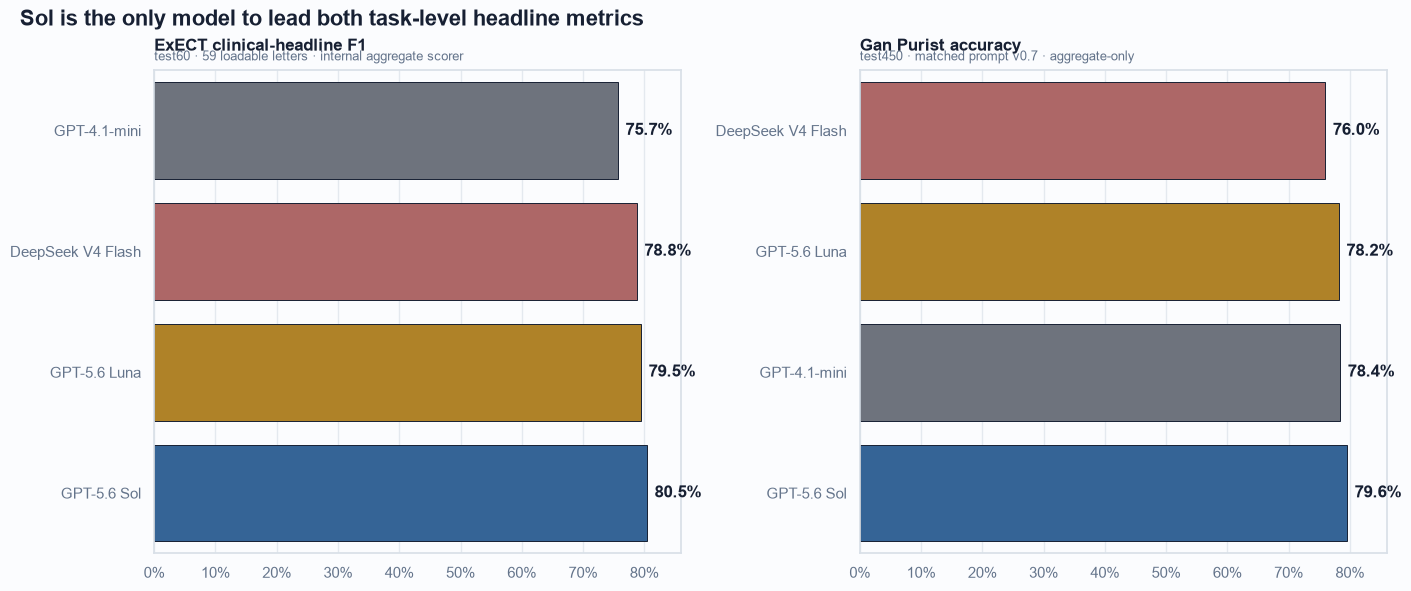

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.8), constrained_layout=True)

for ax, frame, metric, title, subtitle in [
    (axes[0], exect, "f1", "ExECT clinical-headline F1", "test60 · 59 loadable letters · internal aggregate scorer"),
    (axes[1], gan, "purist", "Gan Purist accuracy", "test450 · matched prompt v0.7 · aggregate-only"),
]:
    ranked = frame.sort_values(metric, ascending=True)
    sns.barplot(data=ranked, x=metric, y="model", hue="model", palette=COLORS, legend=False, ax=ax, edgecolor=INK, linewidth=0.7)
    ax.set_xlim(0, 0.86)
    ax.xaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title(title, loc="left")
    ax.text(0, 1.02, subtitle, transform=ax.transAxes, color=MUTED, fontsize=9.5)
    for patch in ax.patches:
        value = patch.get_width()
        ax.text(value + 0.012, patch.get_y() + patch.get_height()/2, f"{value:.1%}", va="center", weight="bold", color=INK)
    ax.grid(axis="y", visible=False)

fig.suptitle("Sol is the only model to lead both task-level headline metrics", x=0.01, ha="left", fontsize=16, fontweight="bold")
plt.show()

### 2. ExECT leadership comes from different precision–recall profiles

+Luna makes the fewest false-positive clinical claims; Sol recovers the most gold facts. The dumbbell view makes that trade-off visible without treating precision and recall as separate leaderboards.

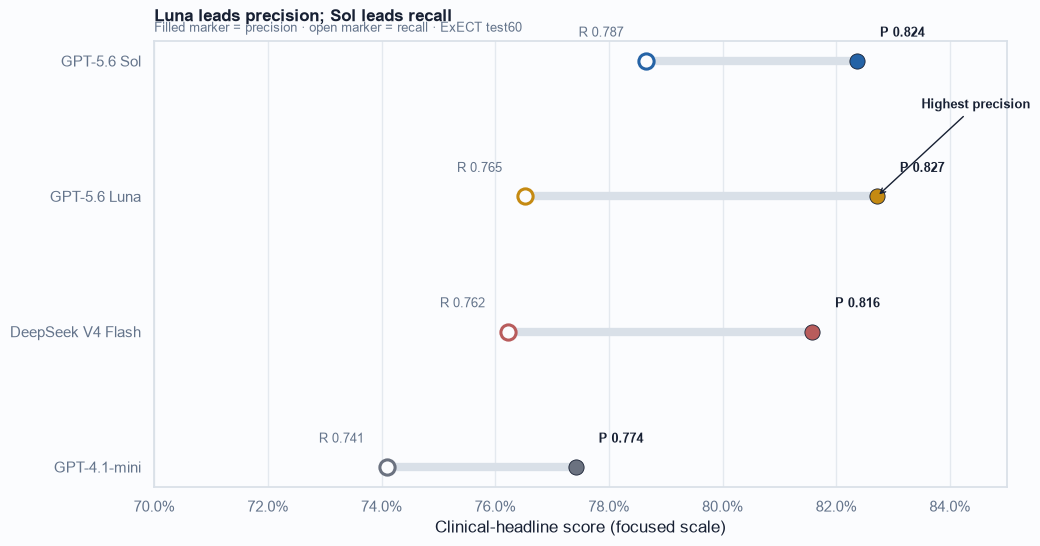

In [5]:
fig, ax = plt.subplots(figsize=(11, 5.8))
plot_data = exect.sort_values("f1")
y = np.arange(len(plot_data))

for i, row in enumerate(plot_data.itertuples()):
    ax.plot([row.recall, row.precision], [i, i], color=GRID, linewidth=6, solid_capstyle="round", zorder=1)
    ax.scatter(row.recall, i, s=120, facecolor=PAPER, edgecolor=COLORS[row.model], linewidth=2.2, zorder=3)
    ax.scatter(row.precision, i, s=120, color=COLORS[row.model], edgecolor=INK, linewidth=0.6, zorder=3)
    ax.text(row.recall - 0.004, i + 0.18, f"R {row.recall:.3f}", ha="right", fontsize=9, color=MUTED)
    ax.text(row.precision + 0.004, i + 0.18, f"P {row.precision:.3f}", ha="left", fontsize=9, color=INK, weight="bold")

ax.set_yticks(y, plot_data["model"])
ax.set_xlim(0.70, 0.85)
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xlabel("Clinical-headline score (focused scale)")
ax.set_ylabel("")
ax.set_title("Luna leads precision; Sol leads recall", loc="left")
ax.text(0, 1.02, "Filled marker = precision · open marker = recall · ExECT test60", transform=ax.transAxes, color=MUTED, fontsize=9.5)
ax.grid(axis="y", visible=False)
ax.annotate("Highest precision", xy=(exect.loc[exect.precision.idxmax(), "precision"], 2), xytext=(0.835, 2.65), arrowprops=dict(arrowstyle="->", color=INK), fontsize=9, weight="bold")
plt.show()

### 3. Sol’s overall ExECT advantage is concentrated in treatment and seizure frequency

+Family-level F1 reveals the mechanism behind the headline. Luna leads Diagnosis and Investigations; Sol leads Prescription and Seizure Frequency. The heatmap uses one sequential colour scale because every cell has the same unit and higher is better.

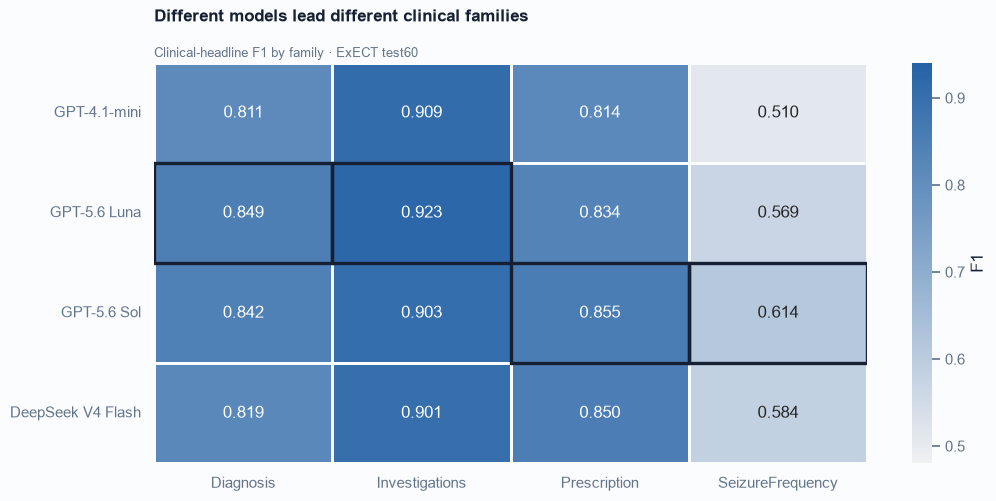

In [6]:
family_order = ["Diagnosis", "Investigations", "Prescription", "SeizureFrequency"]
heat = exect_family.pivot(index="model", columns="family", values="f1").reindex(index=MODEL_ORDER, columns=family_order)

fig, ax = plt.subplots(figsize=(11.5, 5.2))
sns.heatmap(heat, annot=True, fmt=".3f", cmap=sns.light_palette("#2563A6", as_cmap=True), vmin=0.48, vmax=0.94, linewidths=2, linecolor=PAPER, cbar_kws={"label": "F1"}, ax=ax)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Different models lead different clinical families", loc="left", pad=30)
ax.text(0, 1.015, "Clinical-headline F1 by family · ExECT test60", transform=ax.transAxes, color=MUTED, fontsize=9.5)

for j, family in enumerate(family_order):
    leader = heat[family].idxmax()
    i = list(heat.index).index(leader)
    ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False, edgecolor=INK, linewidth=2.4))

plt.show()

### 4. Fidelity changes the Seizure Frequency story

+Headline matching and attribute fidelity are related but distinct. DeepSeek produces the best active-rate fidelity (`0.4375`) even though Sol has the strongest Seizure Frequency headline F1. This is a useful warning against selecting a model from one aggregate alone.

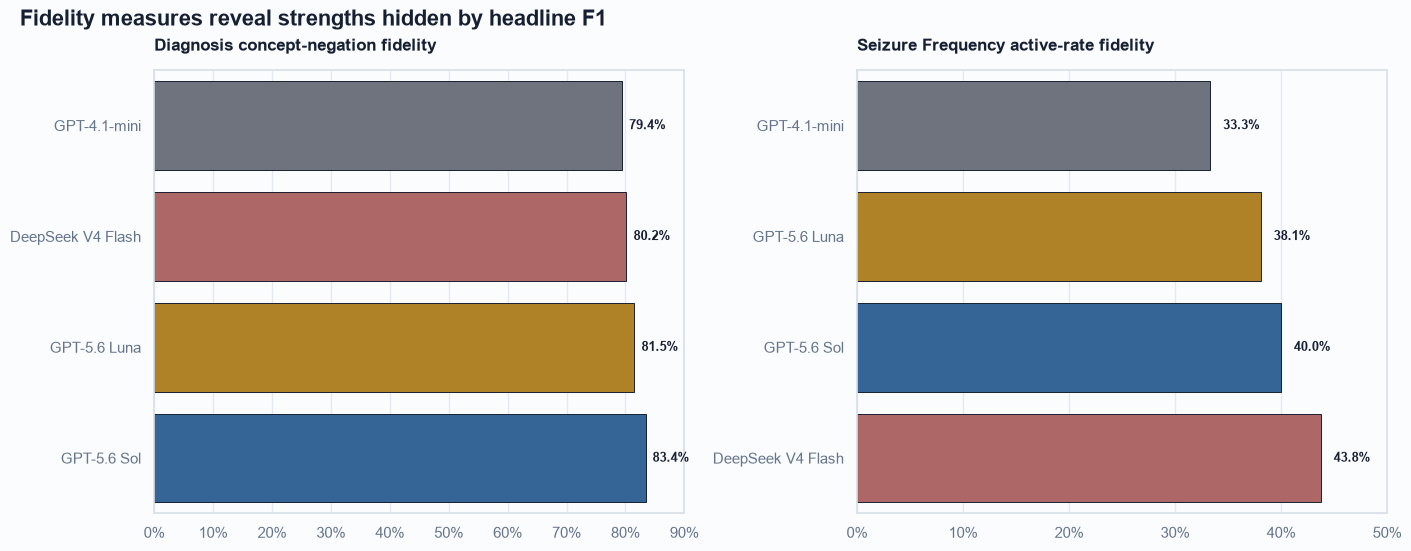

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.4), sharex=False, constrained_layout=True)

for ax, metric, title in zip(axes, ["Diagnosis concept-negation", "SF active-rate fidelity"], ["Diagnosis concept-negation fidelity", "Seizure Frequency active-rate fidelity"]):
    subset = fidelity[fidelity.metric == metric].sort_values("f1")
    sns.barplot(data=subset, x="f1", y="model", hue="model", palette=COLORS, legend=False, edgecolor=INK, linewidth=0.7, ax=ax)
    ax.set_xlim(0, 0.9 if "Diagnosis" in metric else 0.5)
    ax.xaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title(title, loc="left")
    for patch in ax.patches:
        ax.text(patch.get_width() + 0.012, patch.get_y()+patch.get_height()/2, f"{patch.get_width():.1%}", va="center", fontsize=9, weight="bold")
    ax.grid(axis="y", visible=False)

fig.suptitle("Fidelity measures reveal strengths hidden by headline F1", x=0.01, ha="left", fontsize=16, fontweight="bold")
plt.show()

### 5. Gan’s Pragmatic mapping helps every model—but does not change the winner

+Pragmatic accuracy is consistently higher than Purist accuracy. Sol remains first under both mappings; the largest uplift belongs to DeepSeek, showing that some of its errors are category-boundary disagreements rather than wholly wrong frequency states.

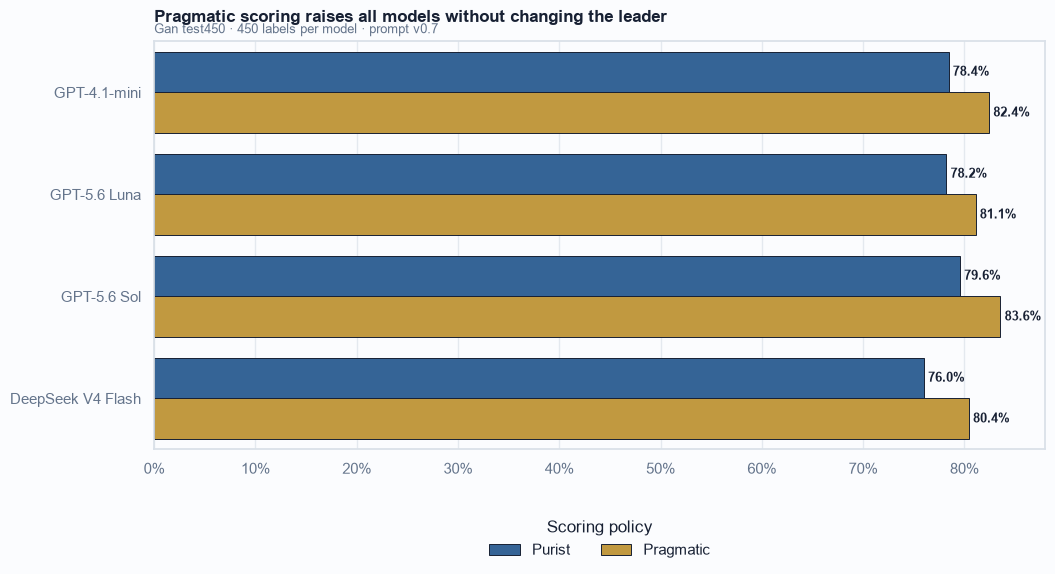

In [8]:
gan_long = gan.melt(id_vars="model", value_vars=["purist", "pragmatic"], var_name="scoring", value_name="accuracy")
gan_long["scoring"] = gan_long["scoring"].str.title()

fig, ax = plt.subplots(figsize=(11.5, 6))
sns.barplot(data=gan_long, y="model", x="accuracy", hue="scoring", palette={"Purist": "#2563A6", "Pragmatic": "#D6A12B"}, edgecolor=INK, linewidth=0.7, ax=ax)
ax.set_xlim(0, 0.88)
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Pragmatic scoring raises all models without changing the leader", loc="left")
ax.text(0, 1.02, "Gan test450 · 450 labels per model · prompt v0.7", transform=ax.transAxes, color=MUTED, fontsize=9.5)
ax.legend(title="Scoring policy", frameon=False, ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.14))
for container in ax.containers:
    ax.bar_label(container, labels=[f"{v:.1%}" for v in container.datavalues], padding=3, fontsize=9, weight="bold")
ax.grid(axis="y", visible=False)
fig.subplots_adjust(bottom=0.20)
plt.show()

### 6. Accuracy and reliability point to the same model—but expose a GPT-4.1-mini caveat

+Sol combines the highest Purist accuracy with the strongest exact-evidence coverage and no parse/schema/label issues. GPT-4.1-mini is only one Purist-correct case ahead of Luna, but its exact-evidence coverage is six percentage points lower.

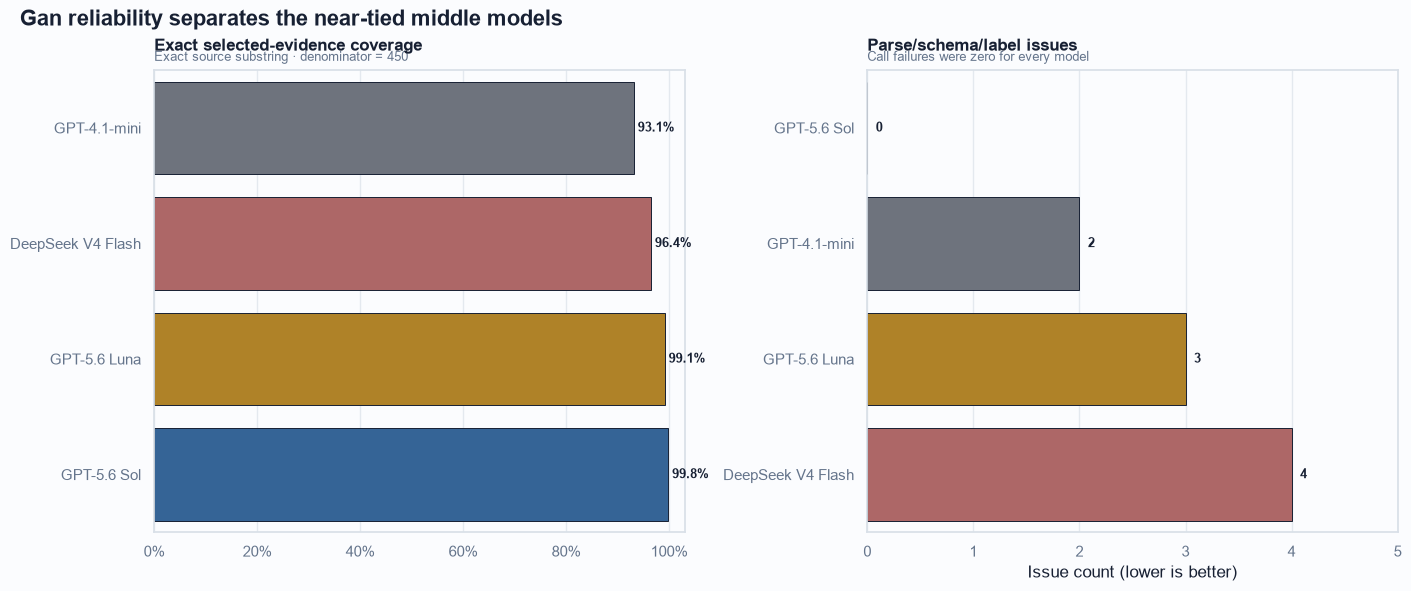

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.8), constrained_layout=True)

ranked = gan.sort_values("exact_evidence_rate")
sns.barplot(data=ranked, x="exact_evidence_rate", y="model", hue="model", palette=COLORS, legend=False, edgecolor=INK, linewidth=0.7, ax=axes[0])
axes[0].set_xlim(0, 1.03)
axes[0].xaxis.set_major_formatter(PercentFormatter(1.0))
axes[0].set_xlabel("")
axes[0].set_ylabel("")
axes[0].set_title("Exact selected-evidence coverage", loc="left")
axes[0].text(0, 1.02, "Exact source substring · denominator = 450", transform=axes[0].transAxes, color=MUTED, fontsize=9.5)
for patch in axes[0].patches:
    axes[0].text(patch.get_width()+0.008, patch.get_y()+patch.get_height()/2, f"{patch.get_width():.1%}", va="center", fontsize=9, weight="bold")
axes[0].grid(axis="y", visible=False)

issues = gan.sort_values("parse_schema_label_issues", ascending=True)
sns.barplot(data=issues, x="parse_schema_label_issues", y="model", hue="model", palette=COLORS, legend=False, edgecolor=INK, linewidth=0.7, ax=axes[1])
axes[1].set_xlim(0, 5)
axes[1].set_xticks(range(0, 6))
axes[1].set_xlabel("Issue count (lower is better)")
axes[1].set_ylabel("")
axes[1].set_title("Parse/schema/label issues", loc="left")
axes[1].text(0, 1.02, "Call failures were zero for every model", transform=axes[1].transAxes, color=MUTED, fontsize=9.5)
for patch in axes[1].patches:
    axes[1].text(patch.get_width()+0.08, patch.get_y()+patch.get_height()/2, f"{int(patch.get_width())}", va="center", fontsize=9, weight="bold")
axes[1].grid(axis="y", visible=False)

fig.suptitle("Gan reliability separates the near-tied middle models", x=0.01, ha="left", fontsize=16, fontweight="bold")
plt.show()

## Explore any retained metric

+Change the parameters below and rerun the cell. The helper keeps task boundaries explicit, chooses an honest zero-based scale for magnitude comparisons, and labels every value.

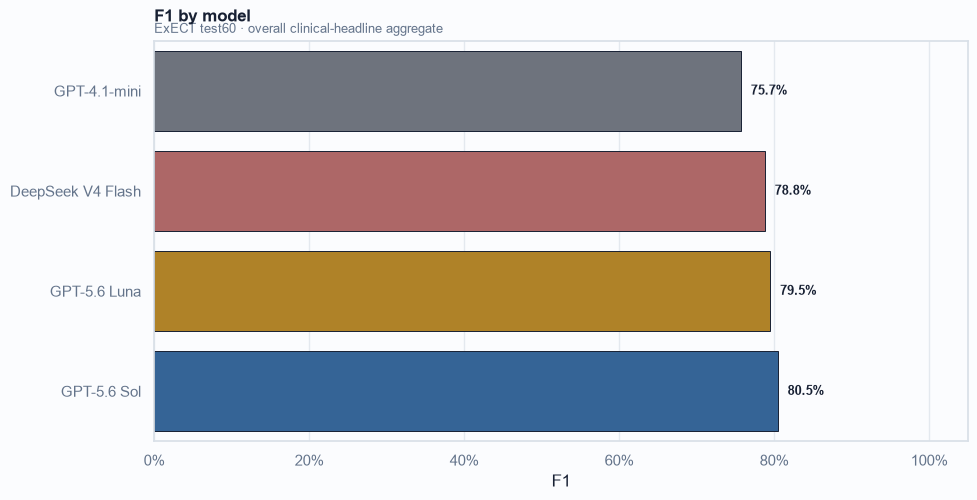

,model,f1
0,GPT-5.6 Sol,0.8047
1,GPT-5.6 Luna,0.7950
2,DeepSeek V4 Flash,0.7881
3,GPT-4.1-mini,0.7572


In [10]:
# Choose one dataset and metric, then rerun this cell.
DATASET_VIEW = "ExECT"  # "ExECT", "ExECT family", "ExECT fidelity", or "Gan"
METRIC = "f1"           # Examples: precision, recall, f1, fp, fn, purist, pragmatic,
                        # exact_evidence_rate, repair_notes, parse_schema_label_issues
FAMILY = "SeizureFrequency"  # Used only for DATASET_VIEW == "ExECT family"

def explore_metric(dataset_view: str, metric: str, family: str | None = None):
    if dataset_view == "ExECT":
        frame, context = exect.copy(), "ExECT test60 · overall clinical-headline aggregate"
    elif dataset_view == "ExECT family":
        if family not in set(exect_family["family"]):
            raise ValueError(f"Choose family from {sorted(exect_family['family'].unique())}")
        frame = exect_family.query("family == @family").copy()
        context = f"ExECT test60 · {family} clinical-headline aggregate"
    elif dataset_view == "ExECT fidelity":
        frame = fidelity.pivot(index="model", columns="metric", values="f1").reset_index()
        context = "ExECT test60 · fidelity companion"
    elif dataset_view == "Gan":
        frame, context = gan.copy(), "Gan test450 · matched prompt v0.7"
    else:
        raise ValueError("Unknown DATASET_VIEW")

    if metric not in frame.columns:
        numeric = frame.select_dtypes(include="number").columns.tolist()
        raise ValueError(f"Metric '{metric}' unavailable. Choose from: {numeric}")

    ranked = frame[["model", metric]].dropna().sort_values(metric)
    fig, ax = plt.subplots(figsize=(10.5, 5.2))
    sns.barplot(data=ranked, x=metric, y="model", hue="model", palette=COLORS, legend=False, edgecolor=INK, linewidth=0.7, ax=ax)
    is_rate = ranked[metric].between(0, 1).all() and metric not in {"fp", "fn", "tp"}
    upper = 1.05 if is_rate else max(ranked[metric].max() * 1.18, 1)
    ax.set_xlim(0, upper)
    if is_rate:
        ax.xaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_xlabel(metric.replace("_", " ").title())
    ax.set_ylabel("")
    ax.set_title(f"{metric.replace('_', ' ').title()} by model", loc="left")
    ax.text(0, 1.02, context, transform=ax.transAxes, color=MUTED, fontsize=9.5)
    for patch in ax.patches:
        value = patch.get_width()
        label = f"{value:.1%}" if is_rate else f"{value:,.0f}" if float(value).is_integer() else f"{value:.3f}"
        ax.text(value + upper*0.012, patch.get_y()+patch.get_height()/2, label, va="center", fontsize=9, weight="bold")
    ax.grid(axis="y", visible=False)
    plt.show()
    return ranked.sort_values(metric, ascending=False).reset_index(drop=True)

explore_metric(DATASET_VIEW, METRIC, FAMILY)

## Takeaways

1. **Sol is the current hosted default if one model must cover both tasks.** It leads both headline metrics and has the cleanest Gan operational record.
2. **The choice is less obvious when a clinical subproblem dominates.** Luna is stronger for ExECT Diagnosis and Investigations; DeepSeek is strongest on active-rate fidelity.
3. **Reliability should accompany accuracy in any model table.** GPT-4.1-mini and Luna are almost tied on Gan Purist accuracy, but their exact-evidence rates differ materially.
4. **Do not collapse these results into one synthetic score.** ExECT measures fact extraction while Gan measures one-label classification; aggregation would hide clinically meaningful trade-offs.

### Provenance and limits

- ExECT source: `experiments/hosted_holdout_panels_20260715.json` plus each condition's aggregate `score_ladder`.
- Gan source: the matched v0.7 panel in the same retained JSON artifact.
- Canonical interpretation: `docs/canon/06_gan_clinical_policy.md`, `docs/canon/10_paper_provenance.md`, and the matched Gan protocol.
- The notebook reads aggregate fields only. It must not be extended to inspect sealed test rows.